In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np

In [3]:
diam = 0.254E-3 # AWG30
area = np.pi * (diam/2)**2

# raicu
l_50K = 0.3053
l_4K = 0.3155
l_Still = 0.2775
l_CP = 0.1965
l_MXC = 0.1965

T_50K = 40
T_4K = 3.5
T_RT = 297

# Thermal Conductivity

In [18]:
area

5.067074790974977e-08

In [4]:
# Calculate the heat load from 50K to 4K for a single strand of a TwP Cu wire that is used to bias the HEMT.

In [5]:
# conductivity, K
# https://trc.nist.gov/cryogenics/materials/OFHC%20Copper/OFHC_Copper_rev1.htm

def conductivity(T):
    # Units = W/m.K
    # Assuming RRR = 50
    a = 1.8743
    b = -0.41538
    c = -0.6018
    d = 0.13294
    e = 0.26426
    f = -0.0219
    g = -0.051276	
    h = 0.0014871	
    i = 0.003723
    
    # Assuming RRR = 100
    # a = 2.2154
    # b = -0.47461
    # c = -0.88068
    # d = 0.13871	
    # e = 0.29505
    # f = -0.02043
    # g = -0.04831
    # h = 0.001281
    # i = 0.003207

    k = 10**((a + c*T**0.5 + e*T + g*T**1.5 + i*T**2) / (1 + b*T**0.5 + d*T + f*T**1.5 + h*T**2))
    
    return k

In [6]:
temp = np.geomspace(1, 300, num=100)
values = conductivity(temp)

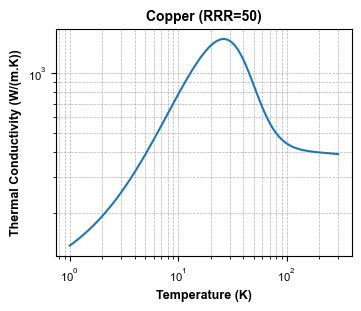

In [7]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in Fig. 5 of 2017greenConnectionRefrigerationSuperconducting (RRR=50)
ax.loglog(temp,values)
ax.set_title("Copper (RRR=50)", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.savefig(f"./cu_k.png",dpi=600)
plt.show()

In [8]:
# Calculate the passive heat load (Watts) flowing from 50K to 4K
# using integration
from scipy.integrate import quad
import math

In [9]:
# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, T_4K, T_50K)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Cu_4K = result * (area/l_4K)
print(f"{PHL_Cu_4K=:.5e}")

The numerical result is 42187.613879 (+-1.165768717e-05)
PHL_Cu_4K=6.77552e-03


In [10]:
# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, T_50K, T_RT)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Cu_50K = result * (area/l_50K)
print(f"{PHL_Cu_50K=:.5e}")

The numerical result is 118010.434566 (+-5.026194093e-07)
PHL_Cu_50K=1.95862e-02


# Electrical Resistivity (complete)

<img src="./Electrical-Resistivity.gif"
     width="400" height="400"
     style="background-color: white;"/>

The electrical resistivity of Copper (ohm-meter) at cryogenic temperatures is shown above.
(https://www.copper.org/resources/properties/cryogenic/)

This is a log-log plot. We observe that the electrical resistivity is nearabout constant from 4K to 20K and rises slowly until 60 K and then slowly tapers off.

We are interested in the electrical resisitvity within the temperature range of 4K to 50K. Thus we can model the resistivity as a piece-wise function that is constant until 20K and rises exponentially from 20K onwards (in a log-log scale). While this does not model the resisitivity at higher temperatures, it is a good approximation model within the temperature range of our interest.

In [11]:
# Data
t_data = np.array([4, 5, 6, 7, 10, 20, 40, 50, 70, 100, 200, 300], dtype=float)
rho_data = np.array([0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.05, 0.09, 0.2, 0.3, 1.0, 1.6], dtype=float) * 1e-8

# Model settings
rho_plateau = 0.03 * 1e-8
T_plateau_hi = 20.0
T_anchor = 70.0
rho_anchor = 0.2 * 1e-8
degree = 4  # >=2 recommended; >=3 is better once you add derivative constraints

def _vander_desc(x, deg):
    """Vandermonde with descending powers: [x^deg, x^(deg-1), ..., 1]."""
    x = np.asarray(x, dtype=float)
    return np.vstack([x**k for k in range(deg, -1, -1)]).T

def _poly_derivative_row_desc(x0, deg):
    """
    Row vector r such that r @ c = p'(x0),
    where c are coefficients in descending-power order.
    """
    r = np.zeros(deg + 1, dtype=float)
    # p(x) = sum_{j=0..deg} c[j] * x^(deg-j)
    # p'(x)= sum c[j]*(deg-j)*x^(deg-j-1), for deg-j >= 1
    for j in range(deg):
        power = deg - j
        r[j] = power * (x0 ** (power - 1))
    return r

def constrained_polyfit_loglog(T, rho, deg, T_plateau, rho_plateau, T_anchor, rho_anchor):
    """
    Fit p(log10(T)) = log10(rho) for T > T_plateau with constraints:
      p(log10(T_plateau)) = log10(rho_plateau)   (C0 at join)
      p'(log10(T_plateau)) = 0                   (C1 smooth at join)
      p(log10(T_anchor)) = log10(rho_anchor)     (anchor)
    Returns coefficients in descending powers for np.polyval.
    """
    T = np.asarray(T, dtype=float)
    rho = np.asarray(rho, dtype=float)

    mask = T > T_plateau
    x = np.log10(T[mask])
    y = np.log10(rho[mask])

    A = _vander_desc(x, deg)

    # Constraint matrix C c = d
    xP = np.log10(T_plateau)
    xA = np.log10(T_anchor)
    CP = _vander_desc(np.array([xP]), deg)[0]          # p(xP)
    dCP = _poly_derivative_row_desc(xP, deg)           # p'(xP)
    CA = _vander_desc(np.array([xA]), deg)[0]          # p(xA)

    C = np.vstack([CP, dCP, CA])
    d = np.array([np.log10(rho_plateau), 0.0, np.log10(rho_anchor)], dtype=float)

    # Solve min ||A c - y||^2 subject to C c = d via KKT system
    ATA = A.T @ A
    ATy = A.T @ y

    KKT = np.block([
        [2.0 * ATA, C.T],
        [C,         np.zeros((C.shape[0], C.shape[0]))]
    ])
    rhs = np.concatenate([2.0 * ATy, d])

    sol = np.linalg.solve(KKT, rhs)
    c = sol[:deg + 1]
    return c

coefficients = constrained_polyfit_loglog(
    t_data, rho_data, degree,
    T_plateau_hi, rho_plateau,
    T_anchor, rho_anchor
)

def resistivity(T):
    T = np.asarray(T, dtype=float)
    out = np.empty_like(T, dtype=float)

    plateau = T <= T_plateau_hi
    out[plateau] = rho_plateau

    if np.any(~plateau):
        logT = np.log10(T[~plateau])
        log_rho = np.polyval(coefficients, logT)
        out[~plateau] = 10.0 ** log_rho

    return out.item() if out.shape == () else out

# Quick sanity checks:
# print(resistivity(20.0), rho_plateau)
# print(resistivity(70.0), rho_anchor)


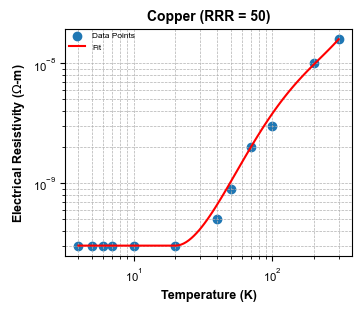

In [13]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.geomspace(4, 300, num=100)
y_vals = resistivity(x_vals)
ax.scatter(t_data, rho_data, label='Data Points')
ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Copper (RRR = 50)", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($\Omega$-m)', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.savefig(f"./cu_rho_v2.png",dpi=600)
plt.show()

In [19]:
# Integrate and average
T_min, T_max = T_4K, T_50K
total_int, _ = quad(resistivity, T_min, T_max)
average_rho = total_int / (T_max - T_min) 

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_4K = average_rho * l_4K / area
print(f"Average Resistance of {l_4K} meter 30 AWG Cu wire between 50K and 4K is {R_Cu_4K=:.3e} ohms")

Average Resistivity (4K-50K): 3.731081e-10 Ohm-m
Average Resistance of 0.3155 meter 30 AWG Cu wire between 50K and 4K is R_Cu_4K=2.323e-03 ohms


In [20]:
# Integrate and average
T_min, T_max = T_50K, T_RT
total_int, _ = quad(resistivity, T_min, T_max)
average_rho = total_int / (T_max - T_min)

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_50K = average_rho * l_50K / area
print(f"Average Resistance of {l_50K} meter 30 AWG Cu wire between 50K and 300K is {R_Cu_50K=:.3e} ohms")

Average Resistivity (4K-50K): 7.975779e-09 Ohm-m
Average Resistance of 0.3053 meter 30 AWG Cu wire between 50K and 300K is R_Cu_50K=4.806e-02 ohms


In [ ]:
# t_data = np.array([4,   5,   6,   7,   10,   20,   40,   50,  70, 100, 200, 300])
# g_data = np.array([0.03,0.03,0.03,0.03, 0.03, 0.03, 0.05, 0.09, 0.2, 0.3, 1.0, 1.6 ]) *1E-8

# # t_data = np.array([t1, t2, t3, t4, t5, t6])
# # g_data = np.array([g1, g2, g3, g4, g5, g6])

# log_t_data = np.log10(t_data)
# log_g_data = np.log10(g_data)

# rho_plateau = 0.03*1E-8 #ohm-m
# T_plateau_hi = 20.0       # K
# T_anchor = 70.0           # K
# rho_anchor = 0.2  # ohm-m
# degree = 5                  # smoothness exponent (>=2 recommended)

# coefficients = np.polyfit(log_t_data, log_g_data, degree)

# def conductivity(T):

#     T = np.asarray(T, dtype=float)
#     out = np.empty_like(T, dtype=float)

#     plateau = T <= T_plateau_hi
#     out[plateau] = rho_plateau

#     x_temp = T[~plateau]
#     log_x_temp = np.log10(x_temp)

#     log_y_pred = 0
#     for i in range(degree+1):
#         log_y_pred += coefficients[i] * log_x_temp**(degree-i)

#     out[~plateau] = log_y_pred
#     return out if out.shape != () else float(out)
#     # log_y_pred = coefficients[0]*log_x_temp**5 + coefficients[1]*log_x_temp**4 + coefficients[2]*log_x_temp**3 + coefficients[3]*log_x_temp**2 + coefficients[4]*log_x_temp**1 + coefficients[5]*log_x_temp**0
#     # log_y_pred = coefficients[0]*log_x_temp**3 + coefficients[1]*log_x_temp**2 + coefficients[2]*log_x_temp**1 + coefficients[3]
#     # return 10**log_y_pred # W per cm-Kelvin 


In [ ]:
# t_data = np.array([4, 5, 6, 7, 10, 20, 40, 50, 70, 100, 200, 300], dtype=float)
# g_data = np.array([0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.05, 0.09, 0.2, 0.3, 1.0, 1.6], dtype=float) * 1e-8

# log_t_data = np.log10(t_data)
# log_g_data = np.log10(g_data)

# rho_plateau = 0.03 * 1e-8  # (whatever unit g_data uses)
# T_plateau_hi = 20.0        # K
# degree = 5

# coefficients = np.polyfit(log_t_data, log_g_data, degree)

# def conductivity(T):
#     T = np.asarray(T, dtype=float)

#     # Allocate output (same shape as T)
#     out = np.empty_like(T, dtype=float)

#     plateau = T <= T_plateau_hi
#     out[plateau] = rho_plateau

#     if np.any(~plateau):
#         x = T[~plateau]
#         log_x = np.log10(x)

#         # Predict in log10-space, then convert back
#         log_y = np.polyval(coefficients, log_x)
#         out[~plateau] = 10.0 ** log_y

#     return out.item() if out.shape == () else out

# Electrical Resistivity (4K-50K)

<img src="./Electrical-Resistivity.gif"
     width="400" height="400"
     style="background-color: white;"/>

The electrical resistivity of Copper (ohm-meter) at cryogenic temperatures is shown above.
(https://www.copper.org/resources/properties/cryogenic/)

This is a log-log plot. We observe that the electrical resistivity is nearabout constant from 4K to 20K and rises slowly until 60 K and then slowly tapers off.

We are interested in the electrical resisitvity within the temperature range of 4K to 50K. Thus we can model the resistivity as a piece-wise function that is constant until 20K and rises exponentially from 20K onwards (in a log-log scale). While this does not model the resisitivity at higher temperatures, it is a good approximation model within the temperature range of our interest.

From https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire, the electrical resistivity for 30AWG Copper wire is provided.

In [ ]:
# --- Given data ---
T_data = np.array([20.0, 77.0]) # assuming the value is constant from 4K to 20K
rhoarea_data = np.array([0.003, 0.04]) # Value in ohm per meter assuwming 30 AWG wire
rho_data = rhoarea_data*area*1E8  # value in 1e-8 ohm-meter

In [ ]:
rho_data

In [ ]:
# --- Log–log transform ---
x = np.log(T_data)
y = np.log(rho_data)

In [ ]:
rho_plateau = rho_data[0] # 0.01527 x 1e-8 ohm·m
T_plateau_hi = 20.0       # K
T_anchor = 77.0           # K
rho_anchor = rho_data[1]  # 0.2036 x 1e-8 ohm·m
p = 2.0                   # smoothness exponent (>=2 recommended)

In [ ]:
# --- compute exponential coefficient ---
dT = T_anchor - T_plateau_hi
alpha = np.log(rho_anchor / rho_plateau) / (dT ** p)

In [ ]:
# --- evaluate full piecewise model ---
def rho_func(T):
    T = np.asarray(T, dtype=float)
    out = np.empty_like(T, dtype=float)

    plateau = T <= T_plateau_hi
    out[plateau] = rho_plateau

    t2 = T[~plateau]
    out[~plateau] = rho_plateau * np.exp(alpha * (t2 - T_plateau_hi) ** p)

    return out if out.shape != () else float(out) # in 10^-8 ohm-meter

In [ ]:
# T_range = np.linspace(4, 80, 100)
T_range = np.geomspace(1, 300, num=100)
rho_vals = rho_func(T_range)

In [ ]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in (https://www.copper.org/resources/properties/cryogenic/)
ax.plot(T_range, rho_vals)
ax.scatter([4, 77], rho_data, color="red")
ax.set_xscale("log")
ax.set_yscale("log")
# --- enable both major and minor grid lines ---
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.set_title("Copper", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($10^{-8} \Omega$-meter)', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

plt.savefig(f"./cu_rho_4K-50K.png",dpi=600)
plt.show()

In [ ]:
# Integrate and average
T_min, T_max = 4, 50
total_int, _ = quad(rho_func, T_min, T_max)
average_rho = total_int / (T_max - T_min) * 1E-8

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_4K = average_rho * l_4K / area
print(f"Average Resistance of {l_4K} meter 30 AWG Cu wire between 50K and 4K is {R_Cu_4K=:.3e} ohms")

# Electrical Resistivity (50K to 300K)

This can be assumed an almost linear relationship in log-log scale.

In [ ]:
x_temp = np.array([50, 100, 200, 300])
r_k = np.array([0.9E-2, 0.3, 1, 1.6]) # 1E-8 ohm-meter

coefficients = np.polyfit(x_temp, r_k, 2)
y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]

def resistivity_50K(x_temp):
    y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]
    return y_pred

In [ ]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.linspace(50,300,100)
y_vals = resistivity_50K(x_vals)
ax.scatter(x_temp, r_k, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Copper", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Electrical Resistivity (ohm * 1E-8 m)', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./cu_rho_50K-300K.png",dpi=600)
# Similar to graph in (https://www.copper.org/resources/properties/cryogenic/)
plt.show()

In [ ]:
# Integrate and average
T_min, T_max = 50, 300
total_int, _ = quad(resistivity_50K, T_min, T_max)
average_rho = total_int / (T_max - T_min) * 1E-8

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_50K = average_rho * l_50K / area
print(f"Average Resistance of {l_50K} meter 30 AWG Cu wire between 50K and 300K is {R_Cu_50K=:.3e} ohms")